In [66]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from finvizfinance.quote import finvizfinance

import warnings
warnings.filterwarnings("ignore")

import os

In [67]:
# stocks list
# stocks = [
#     'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'META', 'V', 'NFLX', 'PFE', 'BABA', 'RACE', 'WMT'
# ] # prop firm common tickers

# stocks = ['GRAB', 'TTD', 'U', 'NOW', 'INTU', 'WDAY', 'DDOG', 'ACN', 'IT', 
#           'ROKU', 'FICO', 'ACN', 'ADBE', 'ZS', 'INTU', 'SOFI', 'OWL', 'SAP',
#           'NKE', 'LULU', 'PYPL', 'MC.PA'
#           ] # tickers to check for longer time period (the ones remaining after other filters)

# stocks = [
#     'OWL', 'SAP', 'NOW', 'PODD', 'TOP', 'MOH', 'TSLX'
# ] # tickers biz + trend insiders

# stocks = ['AMP.MI', 'IGD.MI', 'NEXI.MI', 'REY.MI'] # # TODO: for the italian tickers, we need to remove market cap filter, they are all small cap

# stocks = [
#     'ACIW', 'ALGN', 'APTV', 'BA', 'CLX', 'CSU', 'CTHS', 'ERIE', 
#     'EXLS', 'FMC', 'GME', 'HOOD', 'HUM', 'JD', 'LVS', 'MSTR', 
#     'NVAX', 'NVO', 'ORCL', 'PDD', 'QCOM', 'TEAM', 'TSCO', 'UAA',
#     'UPS', 'VEEV', 'ZTS', 'CE', 'DUOL', 'FE', 'TRI', 'AQN',
#     'FTK', 'QLYS', 'MOH', 'NOA3.DE', 'ABI', 'CMCSA', 'SUI',
#     'U', 'NICE', 'NXPI', 'ENPH', '1KER.MI', 'PUM.MU', 'TGT',
#     'DXCM', 'WYNN', 'MTD', 'GPC', 'SHOP', 'F', 'RMS', 'OKLO',
#     'SCVL'
# ] # tickers rea style "Trading View"

# stocks = [
#     'FICO', 'ACN', 'AMP.MI', 'ADBE', 'IGD.MI', 'ECOR',
#     'BMI', 'NEXI.MI', 'BB', 'SMR', 'UBI.PA', 'ZS',
#     'SOUN', 'AMSC', 'AFX', 'INTU', 'SOFI', 'TTWO', 'BAS', 
#     'LYFT', 'BBW', 'TEP', 'REY.MI', 'RNG', 'WING',
#     'FIGMA', 'TSM', 'NVO', 'DUOL'
# ] # tickers rea style "TUTTE"

stocks = [
    'ORLY', 'AZO', 'CASY', 'ROST', 'CHD', 'TSCO', 'SHW', 'BALL', 'ROL', 
    'IEX', 'AAON', 'AAPL', 'RMS', 'APH', 'DHR', 'MTD'] # tickers coma style


# source directories toggle
use_rankings_main = False          # ..\14_stocks_analysis\00_rankings
use_rankings_sector = False        # ..\14_stocks_analysis\01_rankings_sector
use_stocks_list = True             # manually entered tickers in 'stocks' list above

dir_options = [
    (use_rankings_main, r"..\14_stocks_analysis\00_rankings"),
    (use_rankings_sector, r"..\14_stocks_analysis\01_rankings_sector"),
]
selected_dirs = [path for enabled, path in dir_options if enabled]

if not selected_dirs and not use_stocks_list:
    raise ValueError('Enable at least one source directory or set use_stocks_list = True in Cell 2.')

if not use_stocks_list:
    missing_dirs = [path for path in selected_dirs if not os.path.isdir(path)]
    if missing_dirs:
        raise FileNotFoundError(f'Directories do not exist: {missing_dirs}')

if use_stocks_list:
    print('Using stocks list:', stocks)
else:
    print('Using data directories:')
    for path in selected_dirs:
        print(f' - {path}')


Using stocks list: ['ORLY', 'AZO', 'CASY', 'ROST', 'CHD', 'TSCO', 'SHW', 'BALL', 'ROL', 'IEX', 'AAON', 'AAPL', 'RMS', 'APH', 'DHR', 'MTD']


In [68]:
if use_stocks_list:
    # build df directly from the manually entered stocks list
    df = pd.DataFrame({'symbol': stocks})
    df.head()
else:
    # concatenate all tabular files from selected directories into a single dataframe
    files = []

    for dir_path in selected_dirs:
        dir_files = [
            file for file in os.listdir(dir_path)
            if file.lower().endswith(('.csv', '.xlsx', '.xls'))
        ]
        files.extend([(dir_path, file) for file in dir_files])

    if not files:
        raise ValueError(f'No CSV/XLSX/XLS files found in selected directories: {selected_dirs}')

    def load_table(dir_path, file_name):
        file_path = os.path.join(dir_path, file_name)
        if file_name.lower().endswith('.csv'):
            return pd.read_csv(file_path)
        return pd.read_excel(file_path)

    # file name format like 2603, 2602... first two digits year, last two month
    def extract_date(file_name):
        year = int(file_name[:2]) + 2000
        month = int(file_name[2:4])
        return pd.Timestamp(year=year, month=month, day=1)

    df = pd.concat(
        [
            load_table(dir_path, file_name).assign(
                date=extract_date(file_name),
                source_dir=os.path.basename(dir_path),
            )
            for dir_path, file_name in sorted(files, key=lambda x: (x[0], x[1]))
        ],
        ignore_index=True,
    )

    # lowercase column names
    df.columns = df.columns.str.lower()

    # replace spaces with underscore in column names
    df.columns = df.columns.str.replace(' ', '_')

    df.head()


In [69]:
# print len of dataframe
print(f"Dataframe length: {len(df)}")

Dataframe length: 16


In [70]:
if not use_stocks_list:
    # create a copy of symbol column named 'symbol_copy'
    df['symbol_copy'] = df['symbol']


In [71]:
if not use_stocks_list:
    # the series in df.symbol_copy, should be shifted backwards by 1 row, to align with the stock name in the same row
    df['symbol_copy'] = df['symbol_copy'].shift(-1)


In [72]:
if not use_stocks_list:
    # drop nan in df.unnamed:_0
    df = df.dropna(subset=['unnamed:_0'])


In [73]:
if not use_stocks_list:
    # drop columns 'unnamed: 0', 'symbol' (ignore if already removed)
    df = df.drop(columns=['unnamed:_0', 'symbol'], errors='ignore')

    # rename column 'symbol_copy' to 'symbol' if needed
    if 'symbol_copy' in df.columns and 'symbol' not in df.columns:
        df = df.rename(columns={'symbol_copy': 'symbol'})

    # columns order
    selected_cols = [
        'date', 'symbol', 'stock', 'market_cap', 'price',
        'fair_value_(%)', 'z-score', 'f-score', 'm-score', 'value_generation'
    ]

    # if 'price' is missing, continue without it
    if 'price' not in df.columns:
        selected_cols = [c for c in selected_cols if c != 'price']

    # keep only columns that exist
    selected_cols = [c for c in selected_cols if c in df.columns]
    df = df[selected_cols]


In [74]:
df.columns

Index(['symbol'], dtype='object')

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   symbol  16 non-null     object
dtypes: object(1)
memory usage: 260.0+ bytes


In [76]:
if not use_stocks_list:
    # create a copy of the dataframe
    df_copy = df.copy()

    # keep only date, symbol columns
    df_copy = df_copy[['date', 'symbol']]

    # group by symbol and count the number of occurrences of each symbol
    symbol_counts = df_copy.groupby('symbol').size().reset_index(name='count')

    # sort the dataframe by count in descending order
    symbol_counts = symbol_counts.sort_values(by='count', ascending=False)

    # display the top 10 symbols with the most occurrences
    print(symbol_counts.head(10))


In [77]:
if not use_stocks_list:
    # drop duplicates in df.symbol, keep last occurrence
    df = df.drop_duplicates(subset='symbol', keep='last')

    # merge df with symbol_counts on symbol, keeping only rows that are in df
    df = df.merge(symbol_counts, on='symbol', how='inner')

    # sort df by count in descending order
    df = df.sort_values(by='count', ascending=False)

    display(df.head(10))


In [78]:
if not use_stocks_list:
    # market cap column is object. We need to convert it to numeric, removing any non-numeric characters
    # ("T" indicating trillions, "B" indicating billions, "M" indicating millions, "K" indicating thousands)

    # take last character of market cap column and add a new column 'market_cap_um'
    df['market_cap_um'] = df['market_cap'].str[-1]

    # replace 'T', 'B', 'M', 'K' with "" in market cap column and convert to numeric
    df['market_cap'] = df['market_cap'].str.replace(r'[TBMK]', '', regex=True).astype(float)


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   symbol  16 non-null     object
dtypes: object(1)
memory usage: 260.0+ bytes


In [80]:
if not use_stocks_list:
    # if market cap um is M, market cap / 1000, if market cap um is T, market cap * 1000, if market cap um is B, market cap / 1
    def convert_market_cap(row):
        if row['market_cap_um'] == 'M':
            return row['market_cap'] / 1000
        elif row['market_cap_um'] == 'T':
            return row['market_cap'] * 1000
        elif row['market_cap_um'] == 'B':
            return row['market_cap']
        elif row['market_cap_um'] == 'K':
            return row['market_cap'] / 1000
        else:
            return row['market_cap']

    # apply the function to the dataframe and create a new column 'market_cap_converted'
    df['market_cap_converted'] = df.apply(convert_market_cap, axis=1)


In [81]:
if not use_stocks_list:
    # drop market cap	
    df = df.drop(columns=['market_cap'])

    # rename market cap converted to market cap
    df = df.rename(columns={'market_cap_converted': 'market_cap'})

    # columns order 'date', 'symbol', 'stock', 'price', 'fair value (%)', 'z-score', 'f-score', 'm-score', 'value generation', 'market cap um', 'market cap'
    desired_cols = ['date', 'symbol', 'stock', 'price', 'fair_value_(%)', 'z-score',
    'f-score', 'm-score', 'value_generation', 'market_cap_um', 'market_cap', 'count']
    df = df[[c for c in desired_cols if c in df.columns]]


In [82]:
if not use_stocks_list:
    # --- market cap filter ---
    # drop all rows where market cap um is M and K
    df = df[~df['market_cap_um'].isin(['M', 'K'])]

    # drop all rows where market cap um is B and market cap is less than 10
    df = df[~((df['market_cap_um'] == 'B') & (df['market_cap'] < 10))]

    # rename df.market_cap to market_cap_(B)
    df = df.rename(columns={'market_cap': 'market_cap_(B)'})

    # drop market_cap_um
    df = df.drop(columns=['market_cap_um'])


In [83]:
# add currency column according to the stock exchange where the stock is listed. Need to identify currency based on df.symbol 
# ends with:
# .MI -> EUR
# .DE -> EUR
# .PA -> EUR
# .L -> GBP
# .T -> JPY
# .AX -> AUD
# .SR -> SAR
# .HK -> HKD
# .TO -> CAD
# .NZ -> NZD
# .KL -> MYR
# .MX -> MXN
# if df.symbol does not contain ".", add USD as currency
# if none of the above conditions are met, currency 
def identify_currency(symbol):
    if symbol.endswith('.MI') or symbol.endswith('.DE') or symbol.endswith('.PA'):
        return 'EUR'
    elif symbol.endswith('.L'):
        return 'GBP'
    elif symbol.endswith('.T'):
        return 'JPY'
    elif symbol.endswith('.AX'):
        return 'AUD'
    elif symbol.endswith('.SR'):
        return 'SAR'
    elif symbol.endswith('.HK'):
        return 'HKD'
    elif symbol.endswith('.TO'):
        return 'CAD'
    elif symbol.endswith('.NZ'):
        return 'NZD'
    elif symbol.endswith('.KL'):
        return 'MYR'
    elif symbol.endswith('.MX'):
        return 'MXN'
    elif '.' not in symbol:
        return 'USD'
    else:
        return 'Unknown'
    
# apply the function to the dataframe and create a new column 'currency'
df['currency'] = df['symbol'].apply(identify_currency)

In [84]:
# print Unknown symbols in currency column
print(df[df['currency'] == 'Unknown']['symbol'])

Series([], Name: symbol, dtype: object)


In [85]:
# --- currency filter ---
# keep only EUR and USD stocks
df = df[df['currency'].isin(['EUR', 'USD'])]

In [86]:
if not use_stocks_list:
    # --- solidity filter ---
    # convert z-score, f-score, m-score to numeric
    df['z-score'] = pd.to_numeric(df['z-score'], errors='coerce')
    df['f-score'] = pd.to_numeric(df['f-score'], errors='coerce')
    df['m-score'] = pd.to_numeric(df['m-score'], errors='coerce')

    # drop all rows where z-score is less than 1.81
    # drop all rows where f-score is less than 3
    # drop all rows where m-score is higher than -1.78
    df = df[~((df['z-score'] < 1.81) | (df['f-score'] < 3) | (df['m-score'] > -1.78))]


In [87]:
if not use_stocks_list:
    # --- fair_value_(%) filter ---
    # convert fair_value_(%) to numeric
    df['fair_value_(%)'] = pd.to_numeric(df['fair_value_(%)'], errors='coerce')

    # keep only rows where fair_value_(%) is higher than 0
    df = df[df['fair_value_(%)'] > 0]


In [88]:
# list of tickers in the dataframe
tickers = df['symbol'].tolist()

In [ ]:
# TODO: when we have new data, below code can be used to update the fundamentals cache, 
# by downloading fundamentals for all tickers in the dataframe, 
# keeping only the keys in keys_to_keep, prefixing the columns with "fv_", 
# and writing the cache to a CSV file. This way we can keep the fundamentals cache 
# updated with the latest tickers in the dataframe, 
# without having to download fundamentals for all tickers every time we run the notebook.

# batch fundamentals download for all tickers (keeps only keys_to_keep, prefixes columns, writes cache CSV)
from pathlib import Path
import re
import time

keys_to_keep = ['Company', 'Sector', 'Industry', 'P/E', 'EPS (ttm)',
'Perf Week', 'Market Cap','Forward P/E', 'Perf Month',
'Short Float', 'Perf Quarter', 'P/S', 'EPS this Y',
'Short Ratio', 'Perf Half Y', 'P/B', 'ROA', 'Perf YTD', 'P/C',
'ROE', '52W High', 'Perf Year', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.',
'EV/EBITDA', 'Sales past 3/5Y', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM',
'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom',
'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume',
'Prev Close', 'LT Debt/Eq', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change']

def normalize_fundament_key(key):
    clean_key = re.sub(r'[^0-9a-zA-Z]+', '_', key).strip('_').lower()
    return f'fv_{clean_key}'

key_to_col = {key: normalize_fundament_key(key) for key in keys_to_keep}
fundamentals_rows = []
failed_tickers = []

for t in tickers:
    try:
        stock_obj = finvizfinance(t)
        stock_fundament = stock_obj.ticker_fundament()
        row = {'symbol': t}
        for key in keys_to_keep:
            row[key_to_col[key]] = stock_fundament.get(key)
        fundamentals_rows.append(row)
    except Exception:
        failed_tickers.append(t)
    time.sleep(0.25)

fundamentals_df = pd.DataFrame(fundamentals_rows)

fundamentals_cache_path = Path('14_stocks_analysis/fundamentals_cache.csv')
fundamentals_cache_path.parent.mkdir(parents=True, exist_ok=True)
# fundamentals_df.to_csv(fundamentals_cache_path, index=False)

print(f'Fundamentals downloaded for {len(fundamentals_df)} tickers')
print(f'Fundamentals cache saved to: {fundamentals_cache_path}')

# failed tickers report
if failed_tickers:
    print('Failed tickers:')
    print(failed_tickers)
else:
    print('No failed tickers.')

Fundamentals downloaded for 15 tickers
Fundamentals cache saved to: 14_stocks_analysis\fundamentals_cache.csv
Failed tickers:
['RMS']


In [90]:
# TODO: yahoo finance tickers differs from finviz tickers, look at the below example:
# Fundamentals downloaded for 11 tickers
# Fundamentals cache saved to: 14_stocks_analysis\fundamentals_cache.csv
# Failed tickers:
# ['ADS.DE', 'HEN3.DE', 'HEN.DE', 'BEI.DE'] 
# Need to apply a general solution to align the tickers in the dataframe with the tickers used by finviz,
# for example by removing the market suffixes (.DE, .MI, etc.) before downloading

In [91]:
# load fundamentals from cache CSV (for tests, avoids repeated API calls)
from pathlib import Path

fundamentals_cache_path = Path('14_stocks_analysis/fundamentals_cache.csv')
fundamentals_df = pd.read_csv(fundamentals_cache_path)

print(f'Loaded fundamentals cache: {fundamentals_cache_path}')
print(f'Rows: {len(fundamentals_df)}')

fundamentals_df.head()

Loaded fundamentals cache: 14_stocks_analysis\fundamentals_cache.csv
Rows: 15


,symbol,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_market_cap,fv_forward_p_e,fv_perf_month,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,ORLY,"O'Reilly Automotive, Inc",Consumer Cyclical,Auto Parts,31.59,2.97,0.75%,78.41B,26.26,6.83%,...,92.71,-,-3.55%,5.94M,93.71,"Apr 23, 1993",-2.15% 0.49%,\n\n,"5,424,084",1.08%
1,AZO,Autozone Inc,Consumer Cyclical,Auto Parts,25.03,142.74,4.14%,58.86B,20.41,6.26%,...,3489.29,-,-5.42%,152.12K,3572.38,"Apr 02, 1991",1.75% -0.84%,\n\n,"217,530",2.38%
2,CASY,"Casey's General Stores, Inc",Consumer Cyclical,Specialty Retail,43.32,17.42,2.24%,27.89B,37.89,12.73%,...,737.22,0.73,29.17%,584.49K,754.72,"Oct 20, 1983",16.19% -3.14%,\n\n,"367,911",2.37%
3,ROST,"Ross Stores, Inc",Consumer Cyclical,Apparel Retail,34.43,6.62,3.01%,73.44B,27.92,9.94%,...,221.97,0.64,32.05%,2.61M,227.82,"Aug 08, 1985",5.11% 3.44%,\n\n,"2,893,508",2.64%
4,CHD,"Church & Dwight Co., Inc",Consumer Defensive,Household & Personal Products,32.18,3.01,1.53%,22.95B,24.14,1.19%,...,94.54,0.59,5.50%,2.29M,96.88,"Mar 17, 1980",2.87% 0.33%,\n\n,"1,718,366",2.48%


In [92]:
# merge fundamentals into df on symbol
df = df.merge(fundamentals_df, on='symbol', how='left')

print(f'Merged dataframe rows: {len(df)}')
print(f'Columns after merge: {len(df.columns)}')

df.head()

Merged dataframe rows: 16
Columns after merge: 66


,symbol,currency,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_market_cap,fv_forward_p_e,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,ORLY,USD,"O'Reilly Automotive, Inc",Consumer Cyclical,Auto Parts,31.59,2.97,0.75%,78.41B,26.26,...,92.71,-,-3.55%,5.94M,93.71,"Apr 23, 1993",-2.15% 0.49%,\n\n,"5,424,084",1.08%
1,AZO,USD,Autozone Inc,Consumer Cyclical,Auto Parts,25.03,142.74,4.14%,58.86B,20.41,...,3489.29,-,-5.42%,152.12K,3572.38,"Apr 02, 1991",1.75% -0.84%,\n\n,"217,530",2.38%
2,CASY,USD,"Casey's General Stores, Inc",Consumer Cyclical,Specialty Retail,43.32,17.42,2.24%,27.89B,37.89,...,737.22,0.73,29.17%,584.49K,754.72,"Oct 20, 1983",16.19% -3.14%,\n\n,"367,911",2.37%
3,ROST,USD,"Ross Stores, Inc",Consumer Cyclical,Apparel Retail,34.43,6.62,3.01%,73.44B,27.92,...,221.97,0.64,32.05%,2.61M,227.82,"Aug 08, 1985",5.11% 3.44%,\n\n,"2,893,508",2.64%
4,CHD,USD,"Church & Dwight Co., Inc",Consumer Defensive,Household & Personal Products,32.18,3.01,1.53%,22.95B,24.14,...,94.54,0.59,5.50%,2.29M,96.88,"Mar 17, 1980",2.87% 0.33%,\n\n,"1,718,366",2.48%


In [93]:
# quick check: tickers used in batch download
print('Tickers:', tickers)
print('Number of tickers:', len(tickers))

Tickers: ['ORLY', 'AZO', 'CASY', 'ROST', 'CHD', 'TSCO', 'SHW', 'BALL', 'ROL', 'IEX', 'AAON', 'AAPL', 'RMS', 'APH', 'DHR', 'MTD']
Number of tickers: 16


In [94]:
# quick check: cached fundamentals columns (prefixed with fv_)
fundamentals_df.columns.tolist()[:20]

['symbol',
 'fv_company',
 'fv_sector',
 'fv_industry',
 'fv_p_e',
 'fv_eps_ttm',
 'fv_perf_week',
 'fv_market_cap',
 'fv_forward_p_e',
 'fv_perf_month',
 'fv_short_float',
 'fv_perf_quarter',
 'fv_p_s',
 'fv_eps_this_y',
 'fv_short_ratio',
 'fv_perf_half_y',
 'fv_p_b',
 'fv_roa',
 'fv_perf_ytd',
 'fv_p_c']

In [95]:
# preview merged fundamentals for first rows
df.filter(regex='^fv_').head()

,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_market_cap,fv_forward_p_e,fv_perf_month,fv_short_float,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,"O'Reilly Automotive, Inc",Consumer Cyclical,Auto Parts,31.59,2.97,0.75%,78.41B,26.26,6.83%,2.02%,...,92.71,-,-3.55%,5.94M,93.71,"Apr 23, 1993",-2.15% 0.49%,\n\n,"5,424,084",1.08%
1,Autozone Inc,Consumer Cyclical,Auto Parts,25.03,142.74,4.14%,58.86B,20.41,6.26%,1.83%,...,3489.29,-,-5.42%,152.12K,3572.38,"Apr 02, 1991",1.75% -0.84%,\n\n,"217,530",2.38%
2,"Casey's General Stores, Inc",Consumer Cyclical,Specialty Retail,43.32,17.42,2.24%,27.89B,37.89,12.73%,2.69%,...,737.22,0.73,29.17%,584.49K,754.72,"Oct 20, 1983",16.19% -3.14%,\n\n,"367,911",2.37%
3,"Ross Stores, Inc",Consumer Cyclical,Apparel Retail,34.43,6.62,3.01%,73.44B,27.92,9.94%,2.65%,...,221.97,0.64,32.05%,2.61M,227.82,"Aug 08, 1985",5.11% 3.44%,\n\n,"2,893,508",2.64%
4,"Church & Dwight Co., Inc",Consumer Defensive,Household & Personal Products,32.18,3.01,1.53%,22.95B,24.14,1.19%,3.55%,...,94.54,0.59,5.50%,2.29M,96.88,"Mar 17, 1980",2.87% 0.33%,\n\n,"1,718,366",2.48%


In [96]:
# count how many symbols did not receive fundamentals
missing_fv = df['fv_company'].isna().sum() if 'fv_company' in df.columns else None
print('Symbols with missing fundamentals:', missing_fv)

Symbols with missing fundamentals: 1


In [97]:
# # print failed tickers again (separate output cell)
# print(failed_tickers)

In [98]:
# show first rows from fundamentals cache dataframe
fundamentals_df.head()

,symbol,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_market_cap,fv_forward_p_e,fv_perf_month,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,ORLY,"O'Reilly Automotive, Inc",Consumer Cyclical,Auto Parts,31.59,2.97,0.75%,78.41B,26.26,6.83%,...,92.71,-,-3.55%,5.94M,93.71,"Apr 23, 1993",-2.15% 0.49%,\n\n,"5,424,084",1.08%
1,AZO,Autozone Inc,Consumer Cyclical,Auto Parts,25.03,142.74,4.14%,58.86B,20.41,6.26%,...,3489.29,-,-5.42%,152.12K,3572.38,"Apr 02, 1991",1.75% -0.84%,\n\n,"217,530",2.38%
2,CASY,"Casey's General Stores, Inc",Consumer Cyclical,Specialty Retail,43.32,17.42,2.24%,27.89B,37.89,12.73%,...,737.22,0.73,29.17%,584.49K,754.72,"Oct 20, 1983",16.19% -3.14%,\n\n,"367,911",2.37%
3,ROST,"Ross Stores, Inc",Consumer Cyclical,Apparel Retail,34.43,6.62,3.01%,73.44B,27.92,9.94%,...,221.97,0.64,32.05%,2.61M,227.82,"Aug 08, 1985",5.11% 3.44%,\n\n,"2,893,508",2.64%
4,CHD,"Church & Dwight Co., Inc",Consumer Defensive,Household & Personal Products,32.18,3.01,1.53%,22.95B,24.14,1.19%,...,94.54,0.59,5.50%,2.29M,96.88,"Mar 17, 1980",2.87% 0.33%,\n\n,"1,718,366",2.48%


In [99]:
# number of prefixed fundamentals columns
len([c for c in fundamentals_df.columns if c.startswith('fv_')])

64

In [100]:
# # all listed keys in stock_fundament
# """
# dict_keys(['Company', 'Sector', 'Industry', 'Country', 'Exchange', 'Index', 'P/E', 'EPS (ttm)', 
# 'Insider Own', 'Shs Outstand', 'Perf Week', 'Market Cap', 'Forward P/E', 'EPS next Y', 'Insider Trans', 'Shs Float', 'Perf Month', 
# 'Enterprise Value', 'PEG', 'EPS next Q', 'Inst Own', 'Short Float', 'Perf Quarter', 'Income', 'P/S', 'EPS this Y', 'Inst Trans', 
# 'Short Ratio', 'Perf Half Y', 'Sales', 'P/B', 'EPS next Y Percentage', 'ROA', 'Short Interest', 'Perf YTD', 'Book/sh', 'P/C', 
# 'EPS next 5Y', 'ROE', '52W High', 'Perf Year', 'Cash/sh', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.', 
# 'EV/EBITDA', 'Sales past 3/5Y', 'Gross Margin', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM', 
# 'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Dividend Ex-Date', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom', 
# 'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Target Price', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume', 
# 'Prev Close', 'Employees', 'LT Debt/Eq', 'Earnings', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'Option/Short', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change'])
# """;

# # keys to keep in stock_fundament
# keys_to_keep = ['Company', 'Sector', 'Industry', 'P/E', 'EPS (ttm)', 
# 'Perf Week', 'Market Cap', 'Forward P/E', 'EPS next Y', 'Perf Month', 
# 'Short Float', 'Perf Quarter', 'P/S', 'EPS this Y',  
# 'Short Ratio', 'Perf Half Y', 'P/B', 'ROA', 'Perf YTD', 'P/C', 
# 'ROE', '52W High', 'Perf Year', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.', 
# 'EV/EBITDA', 'Sales past 3/5Y', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM', 
# 'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom', 
# 'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume', 
# 'Prev Close', 'LT Debt/Eq', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change']

# # TODO: 'Perf Month', 'Perf Quarter', 'Perf YTD', 'Perf Half Y', 'Perf Year', 'Perf 3Y', 'Perf 5Y', 'Perf 10Y' should be converted to numeric, removing the "%" character, 
# # then used as one of the first filters to keep only stocks with negative performance

# # TODO: 'EPS past 3/5Y': '37.29% 8.84%' should be split into two separate columns, one for 3Y and one for 5Y, but for now we will keep it as is
# # TODO: 'Sales past 3/5Y': '7.21% 9.24%' should be split into two separate columns, one for 3Y and one for 5Y, but for now we will keep it as is

# stock_fundament_filtered = {key: stock_fundament[key] for key in keys_to_keep if key in stock_fundament}

# print(stock_fundament_filtered)

In [101]:
# drop columns price (if exists) because we will keep only fv_price from fundamentals
if 'price' in df.columns:
    df = df.drop(columns=['price'])

In [102]:
# df.info()

In [103]:
# # sample of merged dataframe with selected fundamentals
# cols_to_show = [c for c in ['symbol', 'stock', 'fv_company', 'fv_sector', 'fv_industry', 'fv_p_e', 'fv_roe', 'fv_profit_margin'] if c in df.columns]
# df[cols_to_show].head(10)

In [104]:
# # rows in merge where at least one fundamentals value exists
# fv_cols = [c for c in df.columns if c.startswith('fv_')]
# df[df[fv_cols].notna().any(axis=1)].head() if fv_cols else df.head()

In [105]:
# # list prefixed fundamentals columns
# [c for c in df.columns if c.startswith('fv_')]

In [106]:
# select all columns that start with "fv_perf_"
perf_cols = [c for c in df.columns if c.startswith('fv_perf_')]

# convert fv_perf_ columns to numeric, removing the "%" character
for col in perf_cols:
    df[col] = pd.to_numeric(df[col].str.replace('%', ''), errors='coerce')

df[perf_cols].head() if perf_cols else df.head()

,fv_perf_week,fv_perf_month,fv_perf_quarter,fv_perf_half_y,fv_perf_ytd,fv_perf_year,fv_perf_3y,fv_perf_5y,fv_perf_10y
0,0.75,6.83,0.07,-8.24,2.74,1.06,56.66,164.96,423.03
1,4.14,6.26,3.09,-11.29,5.33,-0.86,34.03,138.82,358.13
2,2.24,12.73,18.41,33.78,36.55,64.04,230.65,237.95,573.02
3,3.01,9.94,17.56,45.12,26.47,63.16,118.68,75.37,300.04
4,1.53,1.19,7.13,12.16,15.54,-8.06,7.70,10.17,106.33


In [107]:
len(df)

16

In [108]:
# --- performance filters ---
# keep only rows where one of the performance columns is lower than -20
df = df[df[perf_cols].lt(-20).any(axis=1)]

In [109]:
len(df)

1

In [110]:
# df.info()

In [111]:
# --- market cap filter (stocks list only) ---
# fv_market_cap comes from finviz as a string like "1.50B", "337.71M", etc.
# Convert to billions for comparison; skip if using rankings (already filtered there).
if use_stocks_list and 'fv_market_cap' in df.columns:
    def _parse_mc_to_billions(val):
        if pd.isna(val):
            return None
        s = str(val).strip().upper().replace(',', '')
        if s.endswith('T'):
            return float(s[:-1]) * 1000
        elif s.endswith('B'):
            return float(s[:-1])
        elif s.endswith('M'):
            return float(s[:-1]) / 1000
        elif s.endswith('K'):
            return float(s[:-1]) / 1_000_000
        try:
            return float(s)
        except ValueError:
            return None

    fv_mc_b = df['fv_market_cap'].apply(_parse_mc_to_billions)
    df = df[~(fv_mc_b.notna() & (fv_mc_b < 10))]


In [112]:
len(df)

1

In [113]:
# list of symbols in the final dataframe
final_symbols = df['symbol'].tolist()
final_symbols

['BALL']

In [114]:
# drop duplicates from final_symbols
final_symbols = list(set(final_symbols))

In [ ]:
# TODO: uncomment below code to download historical data for the final symbols, and save it to a CSV file. This way we can have the historical data for the selected stocks, and we can use it in the next steps of the analysis.
# Download historical data from yf API
data = yf.download(final_symbols, group_by='ticker', period='max')

# # download data to csv
# data.to_csv("final_symbols.csv")

[*********************100%***********************]  1 of 1 completed


In [116]:
# Load the CSV with MultiIndex columns (Tickers, OHLCV)
data = pd.read_csv("final_symbols.csv", header=[0,1], index_col=0)

# Drop any rows that are completely NaN (e.g. 'Date' row)
data = data.dropna(how='all')

# Convert all values to float
data = data.astype(float)

# Show the result
data.head()

Ticker          BALL                                        
Price           Open      High       Low     Close    Volume
Date                                                        
1973-02-21  0.127246  0.127246  0.127246  0.127246   57600.0
1973-02-22  0.125466  0.125466  0.125466  0.125466  140800.0
1973-02-23  0.120127  0.120127  0.120127  0.120127  288000.0
1973-02-26  0.113009  0.113009  0.113009  0.113009  345600.0
1973-02-27  0.113009  0.113009  0.113009  0.113009  243200.0

In [117]:
from market_profile import MarketProfile

# calculate POC price for each ticker in final_symbols
poc = {}
# market_profiles = {} # need to store the market profile objects for later use in the notebook (plotting, etc.) 

for ticker in final_symbols:
    try:
        ticker_data = data[ticker].dropna()
        if ticker_data.empty:
            print(f"No data available for {ticker}.")
            continue

        mp = MarketProfile(ticker_data)
        mp_slice = mp[ticker_data.index.min():ticker_data.index.max()]
        # market_profiles[ticker] = mp_slice

        # Different versions can expose POC differently; handle common cases
        if hasattr(mp_slice, 'poc_price'):
            poc[ticker] = mp_slice.poc_price
        # elif hasattr(mp_slice, 'profile') and 'POC' in mp_slice.profile:
        #     poc[ticker] = mp_slice.profile['POC']
        # elif hasattr(mp_slice, '__getitem__'):
        #     try:
        #         poc[ticker] = mp_slice['POC']
        #     except Exception:
        #         poc[ticker] = None
        else:
            poc[ticker] = None

    except KeyError:
        print(f"Data for {ticker} not found in the dataset.")

In [118]:
# poc dict to dataframe
poc_df = pd.DataFrame.from_dict(poc, orient='index', columns=['poc_price']).reset_index().rename(columns={'index': 'symbol'})

poc_df.head()

,symbol,poc_price
0,BALL,1.25


In [119]:
# merge poc_df with df on symbol
df = df.merge(poc_df, on='symbol', how='left')

df.head()

,symbol,currency,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_market_cap,fv_forward_p_e,...,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change,poc_price
0,BALL,USD,Ball Corp,Consumer Cyclical,Packaging & Containers,19.42,3.32,3.52,17.16B,14.36,...,1.34,17.18%,2.23M,64.48,"Dec 17, 1973",1.47% 7.51%,\n\n,"2,468,659",1.75%,1.25


In [120]:
# --- poc filter ---
# keep only rows where poc_price is lower than fv_price
df = df[df['poc_price'] < df['fv_price']]

In [121]:
# TODO: optional next step: inside trader data can be fetched in a separate batch process

In [122]:
# print length of dataframe
print("Number of rows in the dataframe:", len(df))

# print lenght of unique symbols in the dataframe (for comparison with the original dataframe)
print("Number of unique symbols in the dataframe:", df['symbol'].nunique())

Number of rows in the dataframe: 1
Number of unique symbols in the dataframe: 1


In [123]:
df.head(10)

,symbol,currency,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_market_cap,fv_forward_p_e,...,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change,poc_price
0,BALL,USD,Ball Corp,Consumer Cyclical,Packaging & Containers,19.42,3.32,3.52,17.16B,14.36,...,1.34,17.18%,2.23M,64.48,"Dec 17, 1973",1.47% 7.51%,\n\n,"2,468,659",1.75%,1.25


In [124]:
# # TODO:
# # Warren Buffett â€” Quality Compounder Stock Screener
# All of the following: # Quality growth stocks with strong fundamentals
#   Debt Ratio < 0.5
#   EPS Basic > EPS Basic (4Q ago) by at least 10 %
#   FCF to Net Income > 0.1
#   PE Ratio TTM < 25
#   Market Cap > 500m
#   Earnings Per Share, Basic (4Q ago) > Earnings Per Share, Basic (8Q ago)
#   Free Cash Flow > 0
#   Earnings Per Share, Basic > 0
#   D TTM ROIC (Lower), Line â‰¥ 0.1
#   D TTM ROE (Lower), Line â‰¥ 0.15

In [125]:
# # TODO:
# # Peter Lynch â€” GARP (Growth at a Reasonable Price) Stock Screener
# All of the following: # Growth at a Reasonable Price using Peter Lynchâ€™s core principles
#   EPS Basic > EPS Basic (4Q ago) by at least 25 %
#   PE Ratio TTM â‰¤ 30
#   Revenue > Revenue (4Q ago) by at least 15 %
#   Debt Ratio < 1
#   Market-Cap â‰¥ 500m
#   Earnings Per Share, Basic > 0
#   Free Cash Flow > 0

In [126]:
import plotly.io as pio
pio.renderers.default = 'vscode'
import plotly.express as px
import plotly.graph_objects as go

In [127]:
# function to calculate 10 years and 5 years ago dates
from datetime import datetime, timedelta

def find_date_years_ago(years):
    today = datetime.today()
    try:
        return today.replace(year=today.year - years)
    except ValueError:
        # Handle February 29 for leap years
        return today.replace(month=2, day=28, year=today.year - years)
    
# call the function to find the date 10 years ago and 5 years ago
date_10_years_ago = find_date_years_ago(10) 
date_5_years_ago = find_date_years_ago(5)

# print the dates
print("Date 10 years ago:", date_10_years_ago.strftime('%Y-%m-%d'))
print("Date 5 years ago:", date_5_years_ago.strftime('%Y-%m-%d'))

Date 10 years ago: 2016-04-18
Date 5 years ago: 2021-04-18


In [128]:
def plot_volume_profile(ticker):
    # Use the stock data from our df
    df_stock = data[ticker].dropna()

    # Convert the stock to datetime if needed
    if not isinstance(df_stock.index, pd.DatetimeIndex):
        df_stock.index = pd.to_datetime(df_stock.index)

    # plot
    hist = go.Histogram(
        y=df_stock['Close'],
        x=df_stock['Volume'],
        nbinsy=150,
        orientation='h',
        name='Volume Profile',
        marker_color='#B0C4DE',
        opacity=0.5,
        xaxis='x2',
    )

    line = go.Scatter(
        x=df_stock.index,
        y=df_stock['Close'],
        mode='lines',
        name='Close',
        marker_color='blue',
        xaxis='x',
        yaxis='y',
    )

    fig = go.Figure([hist, line])

    fig.update_layout(
        xaxis=dict(
            title='Date',
            anchor='y',
            domain=[0, 1],
            showgrid=False,
            side='bottom'
        ),
        xaxis2=dict(
            title='Sum of Volume',
            overlaying='x',
            side='top',
            showgrid=False
        ),
        yaxis=dict(
            title='Close Price',
            showgrid=True
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        height=600,
        title=f'Volume Profile & {ticker} Close Prices'
    )

    fig.show()

In [129]:
def plot_volume_profile_10y_5y(ticker):
    # Use the stock data from our df
    df_stock = data[ticker].dropna()

    # Convert the stock to datetime if needed
    if not isinstance(df_stock.index, pd.DatetimeIndex):
        df_stock.index = pd.to_datetime(df_stock.index)

    # Filter data for the last 10 years and 5 years
    df_10y = df_stock[df_stock.index >= date_10_years_ago]
    df_5y = df_stock[df_stock.index >= date_5_years_ago]

    def _plot_single_profile(df_period, period_label, color):
        hist = go.Histogram(
            y=df_period['Close'],
            x=df_period['Volume'],
            nbinsy=150,
            orientation='h',
            name=f'Volume Profile ({period_label})',
            marker_color=color,
            opacity=0.5,
            xaxis='x2',
        )

        line = go.Scatter(
            x=df_period.index,
            y=df_period['Close'],
            mode='lines',
            name='Close',
            marker_color='blue',
            xaxis='x',
            yaxis='y',
        )

        fig = go.Figure([hist, line])

        fig.update_layout(
            xaxis=dict(
                title='Date',
                anchor='y',
                domain=[0, 1],
                showgrid=False,
                side='bottom'
            ),
            xaxis2=dict(
                title='Sum of Volume',
                overlaying='x',
                side='top',
                showgrid=False
            ),
            yaxis=dict(
                title='Close Price',
                showgrid=True
            ),
            legend=dict(
                orientation='h',
                yanchor='bottom',
                y=1.02,
                xanchor='right',
                x=1
            ),
            height=600,
            title=f'Volume Profile ({period_label}) & {ticker} Close Prices'
        )

        fig.show()

    # Separate plots: one for 10Y and one for 5Y
    _plot_single_profile(df_10y, '10Y', '#B0C4DE')
    _plot_single_profile(df_5y, '5Y', '#ADD8E6')

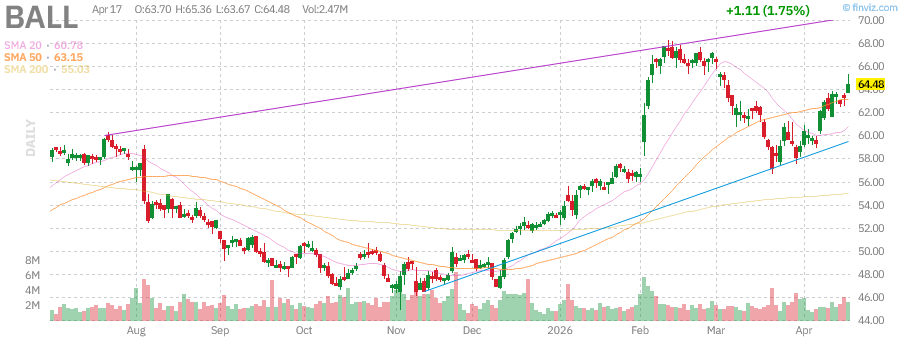

In [130]:
# --- chart printing ---
from pathlib import Path
from IPython.display import Image, display

output_dir = Path('asset')
output_dir.mkdir(parents=True, exist_ok=True)

failed_chart_tickers = []

for ticker in df.symbol.dropna().unique():
    try:
        stock_obj = finvizfinance(ticker)
        stock_obj.ticker_charts(out_dir=str(output_dir))
        plot_volume_profile(ticker)
        plot_volume_profile_10y_5y(ticker)

        candidate_paths = [
            output_dir / f'{ticker}.jpg',
            output_dir / f'{ticker}.jpeg',
            Path(f'{ticker}.jpg'),
            Path(f'{ticker}.jpeg'),
        ]
        image_path = next((p for p in candidate_paths if p.exists()), None)

        if image_path is not None:
            display(Image(filename=str(image_path)))
        else:
            failed_chart_tickers.append(ticker)
    except Exception:
        failed_chart_tickers.append(ticker)

if failed_chart_tickers:
    print('Chart image not available for:')
    print(failed_chart_tickers)